# Figure 6 - Intervention Matrix

Sections 5 and 6 diagnose plasticity loss; Section 6.2 asks what actually mitigates it. This notebook compares plain DQN training against six interventions, across the Appendix A.2 architectures:

- **two_hot** - replace the scalar Q-value head with a categorical (two-hot) distributional head, following Farebrother et al.
- **reset_last_layer** - periodically reinitialize just the output layer.
- **weight_decay** - add L2 regularization to the optimizer.
- **spectral_norm** - constrain every linear/conv layer's spectral norm to 1.
- **layernorm** - add LayerNorm after each hidden layer.
- **shrink_and_perturb** - periodically shrink weights toward zero and add fresh-model noise (Ash & Adams).

Each architecture/intervention pair is trained and probed exactly like Figure 3/5, so the resulting `plasticity_loss` column is directly comparable across the two figures.

In [1]:
import os
from pathlib import Path

import src

ROOT = Path(src.__file__).resolve().parent.parent
DATA_ROOT = ROOT / "data"
OUTPUT_ROOT = ROOT / "outputs"
FIGURES_DIR = OUTPUT_ROOT / "figures"
TABLES_DIR = OUTPUT_ROOT / "tables"
CHECKPOINTS_DIR = OUTPUT_ROOT / "checkpoints"
for directory in (OUTPUT_ROOT, FIGURES_DIR, TABLES_DIR, CHECKPOINTS_DIR):
    directory.mkdir(parents=True, exist_ok=True)

MPLCONFIGDIR = OUTPUT_ROOT / "matplotlib_cache"
MPLCONFIGDIR.mkdir(exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(MPLCONFIGDIR))

ROOT

PosixPath('/Users/mahdigheidi/Documents/Univ/Masters-Study-Project')

## Imports

Most interventions (`reset_last_layer`, `weight_decay`, `spectral_norm`, `layernorm`, `shrink_and_perturb`) are already supported by the shared DQN loop's config fields and `maybe_apply_periodic_interventions` — they need no extra code here beyond setting the right config field. Only `two_hot` changes the training loop itself (a distributional head needs its own action-selection and loss function), so that piece is built inline below.

In [2]:
import copy
import random
from dataclasses import asdict, dataclass, replace
from typing import Callable, List, Optional, Sequence, Tuple

import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

from src.agents.replay_buffer import ReplayBuffer
from src.experiments.dqn_classification import (
    DEVICE,
    ClassificationDQNConfig,
    build_environment,
    build_optimizer,
    collect_transition,
    epsilon_at_step,
    load_dataset,
    maybe_apply_periodic_interventions,
    optimizer_factory_from_config,
    set_seed,
    train_dqn_step,
)
from src.experiments.plasticity import PlasticityProbeConfig, measure_plasticity_loss
from src.models.cnn import CNN
from src.models.mlp import MLP
from src.models.vit import VisionTransformer

DEVICE

device(type='cpu')

## Run Configuration

`InterventionRunConfig` adds which `intervention` to apply and the two-hot head's bin count/value range. `configure_intervention` maps an intervention name onto the right combination of config fields (e.g. `"weight_decay"` just sets `weight_decay=1e-4`; `"two_hot"` doesn't change any shared-loop field at all, since it's handled by the separate training path below).

In [3]:
INTERVENTIONS = (
    "neither",
    "two_hot",
    "reset_last_layer",
    "weight_decay",
    "spectral_norm",
    "layernorm",
    "shrink_and_perturb",
)


@dataclass
class InterventionRunConfig(ClassificationDQNConfig):
    intervention: str = "neither"
    two_hot_bins: int = 51
    two_hot_min: float = -10.0
    two_hot_max: float = 10.0
    probe_steps: int = 2_000
    num_probe_tasks: int = 10
    probe_batch_size: int = 512


def configure_intervention(base: InterventionRunConfig, intervention: str) -> InterventionRunConfig:
    if intervention not in INTERVENTIONS:
        raise ValueError(f"Unknown intervention: {intervention}")

    config = replace(
        base,
        intervention=intervention,
        use_layernorm=False,
        spectral_norm=False,
        weight_decay=0.0,
        reset_last_layer_every=None,
        shrink_perturb_every=None,
    )
    if intervention == "weight_decay":
        return replace(config, weight_decay=1e-4)
    if intervention == "spectral_norm":
        return replace(config, spectral_norm=True)
    if intervention == "layernorm":
        return replace(config, use_layernorm=True)
    if intervention == "reset_last_layer":
        return replace(config, reset_last_layer_every=config.target_update_period)
    if intervention == "shrink_and_perturb":
        return replace(config, shrink_perturb_every=config.target_update_period)
    return config

## Model Factory

Every architecture is available for every intervention except `two_hot`, which needs `10 * two_hot_bins` output units (one categorical distribution per action) instead of 10 scalar Q-values. `resnet18` is listed in the paper's architecture set but has no implementation in `src.models` yet, so it raises a clear error if selected rather than silently falling back to something else.

In [4]:
def apply_spectral_normalization(module: nn.Module) -> nn.Module:
    for name, child in module.named_children():
        if isinstance(child, (nn.Linear, nn.Conv2d)):
            setattr(module, name, nn.utils.spectral_norm(child))
        else:
            apply_spectral_normalization(child)
    return module


def build_intervention_model_factory(
    config: InterventionRunConfig,
    input_shape: Sequence[int],
) -> Callable[[], nn.Module]:
    output_dim = 10 * config.two_hot_bins if config.intervention == "two_hot" else 10

    def factory() -> nn.Module:
        if config.architecture == "mlp":
            model = MLP(
                input_shape=input_shape,
                output_dim=output_dim,
                hidden_dim=config.hidden_dim,
                use_layernorm=config.use_layernorm,
                spectral_norm=config.spectral_norm,
            )
        elif config.architecture == "cnn":
            model = CNN(
                input_shape=input_shape,
                output_dim=output_dim,
                conv_channels=config.cnn_channels,
                fc_dim=config.cnn_fc_dim,
                use_layernorm=config.use_layernorm,
                spectral_norm=config.spectral_norm,
            )
        elif config.architecture == "resnet18":
            raise ValueError(
                "architecture='resnet18' is configured, but no ResNet18 "
                "implementation exists in src.models."
            )
        elif config.architecture == "vit":
            model = VisionTransformer(
                input_shape=input_shape,
                output_dim=output_dim,
                patch_size=3,
                dim=256,
                depth=1,
                mlp_dim=1024,
                dropout=0.1,
            )
        else:
            raise ValueError(f"Unknown architecture: {config.architecture}")

        if config.spectral_norm and config.architecture == "vit":
            model = apply_spectral_normalization(model)
        return model

    return factory

## Two-Hot Distributional Head

Following Farebrother et al., each action's scalar Q-value is replaced by a categorical distribution over `two_hot_bins` fixed support values between `two_hot_min` and `two_hot_max`. `encode` turns a scalar target into a two-hot distribution (weight split between the two nearest bins); `expected_value` turns a predicted distribution back into a scalar for action selection.

In [5]:
class TwoHotEncoding:
    def __init__(self, bins: int = 51, vmin: float = -10.0, vmax: float = 10.0, device=DEVICE):
        self.bins = int(bins)
        self.vmin = float(vmin)
        self.vmax = float(vmax)
        self.support = torch.linspace(vmin, vmax, bins, device=device)

    def to(self, device) -> "TwoHotEncoding":
        self.support = self.support.to(device)
        return self

    def encode(self, values: torch.Tensor) -> torch.Tensor:
        values = values.clamp(self.vmin, self.vmax)
        position = (values - self.vmin) / (self.vmax - self.vmin) * (self.bins - 1)
        lower = torch.floor(position).long().clamp(0, self.bins - 1)
        upper = torch.ceil(position).long().clamp(0, self.bins - 1)
        upper_weight = position - lower.float()
        lower_weight = 1.0 - upper_weight

        distribution = torch.zeros(*values.shape, self.bins, device=values.device)
        distribution.scatter_add_(-1, lower.unsqueeze(-1), lower_weight.unsqueeze(-1))
        distribution.scatter_add_(-1, upper.unsqueeze(-1), upper_weight.unsqueeze(-1))
        return distribution

    def expected_value(self, logits: torch.Tensor) -> torch.Tensor:
        probs = torch.softmax(logits, dim=-1)
        return (probs * self.support.to(logits.device)).sum(dim=-1)


@torch.no_grad()
def select_two_hot_action(
    model: nn.Module,
    observation: torch.Tensor,
    encoding: TwoHotEncoding,
    epsilon: float,
    device=DEVICE,
) -> int:
    if random.random() < epsilon:
        return random.randrange(10)
    logits = model(observation.unsqueeze(0).to(device)).view(1, 10, encoding.bins)
    q_values = encoding.expected_value(logits)
    return int(q_values.argmax(dim=1).item())


def collect_two_hot_transition(
    env,
    model: nn.Module,
    replay: ReplayBuffer,
    encoding: TwoHotEncoding,
    epsilon: float,
    device=DEVICE,
) -> None:
    observation = env.sample_observation()
    action = select_two_hot_action(model, observation, encoding, epsilon, device=device)
    next_observation, reward, _ = env.step(action)
    replay.push(observation, action, reward, next_observation)


def two_hot_dqn_loss(
    model: nn.Module,
    target_model: nn.Module,
    batch: Tuple[torch.Tensor, ...],
    gamma: float,
    encoding: TwoHotEncoding,
) -> torch.Tensor:
    states, actions, rewards, next_states = batch
    logits = model(states).view(states.size(0), 10, encoding.bins)
    chosen_logits = logits.gather(
        1, actions.view(-1, 1, 1).expand(-1, 1, encoding.bins)
    ).squeeze(1)

    with torch.no_grad():
        next_logits = target_model(next_states).view(next_states.size(0), 10, encoding.bins)
        next_q = encoding.expected_value(next_logits).max(dim=1).values
        target_values = rewards + gamma * next_q
        target_distribution = encoding.encode(target_values)

    log_probs = F.log_softmax(chosen_logits, dim=-1)
    return -(target_distribution * log_probs).sum(dim=-1).mean()


def train_two_hot_step(
    model: nn.Module,
    target_model: nn.Module,
    optimizer: torch.optim.Optimizer,
    replay: ReplayBuffer,
    config: InterventionRunConfig,
    encoding: TwoHotEncoding,
    device=DEVICE,
) -> float:
    batch = replay.sample(config.batch_size, device=device)
    loss = two_hot_dqn_loss(model, target_model, batch, config.gamma, encoding)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()
    return float(loss.detach().cpu().item())

## Training + Probing per Intervention

`run_intervention_config` trains one architecture/intervention pair. It branches on `config.intervention == "two_hot"` to use the distributional collect/train functions above; every other intervention reuses the shared `collect_transition`/`train_dqn_step` loop plus `maybe_apply_periodic_interventions`, which already implements last-layer resets and shrink-and-perturb from the config fields `configure_intervention` set.

In [6]:
def run_intervention_config(config: InterventionRunConfig) -> dict:
    print(f"Running intervention config: {asdict(config)}")
    set_seed(config.seed)
    dataset, input_shape = load_dataset(config)
    env = build_environment(config, dataset)
    model_factory = build_intervention_model_factory(config, input_shape)
    model = model_factory().to(DEVICE)
    initial_model = copy.deepcopy(model).to(DEVICE)
    target_model = copy.deepcopy(model).to(DEVICE)
    optimizer = build_optimizer(config, model)
    replay = ReplayBuffer(config.replay_capacity)
    encoding = TwoHotEncoding(config.two_hot_bins, config.two_hot_min, config.two_hot_max, DEVICE)

    for _ in range(config.warmup_steps):
        if config.intervention == "two_hot":
            collect_two_hot_transition(env, model, replay, encoding, epsilon=1.0, device=DEVICE)
        else:
            collect_transition(env, model, replay, epsilon=1.0, device=DEVICE)

    last_loss = float("nan")
    for step in range(1, config.train_steps + 1):
        epsilon = epsilon_at_step(config, step)
        if config.intervention == "two_hot":
            collect_two_hot_transition(env, model, replay, encoding, epsilon, device=DEVICE)
            last_loss = train_two_hot_step(
                model, target_model, optimizer, replay, config, encoding, device=DEVICE,
            )
        else:
            collect_transition(env, model, replay, epsilon, device=DEVICE)
            last_loss = train_dqn_step(model, target_model, optimizer, replay, config, device=DEVICE)

        maybe_apply_periodic_interventions(model, model_factory, config, step, device=DEVICE)

        if step % config.target_update_period == 0:
            target_model.load_state_dict(model.state_dict())

    inputs = replay.sample_states(config.probe_batch_size, device=DEVICE)
    probe_config = PlasticityProbeConfig(
        steps=config.probe_steps, num_tasks=config.num_probe_tasks, batch_size=config.probe_batch_size,
    )
    result = measure_plasticity_loss(
        model, model_factory, inputs, optimizer_factory_from_config(config), probe_config,
        baseline_model=initial_model,
    )

    return {
        "seed": config.seed,
        "observation_space": config.observation_space,
        "environment": config.environment,
        "architecture": config.architecture,
        "intervention": config.intervention,
        "probe_loss": result.probe_loss,
        "initial_probe_loss": result.baseline_probe_loss,
        "plasticity_loss": result.plasticity_loss,
        "last_training_loss": last_loss,
    }


def run_intervention_matrix(
    configs: Sequence[InterventionRunConfig], save_path: Optional[str] = None,
) -> pd.DataFrame:
    df = pd.DataFrame([run_intervention_config(config) for config in configs])
    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        df.to_csv(save_path, index=False)
        print(f"Saved intervention matrix table to {save_path}")
    return df

## Smoke vs. Paper-Scale Matrix

`make_smoke_configs` runs 5 cheap architecture/intervention combinations. `make_intervention_matrix_configs` reproduces the full paper matrix: every architecture (MLP, CNN, ResNet18, ViT — note ResNet18 will raise until it's implemented) crossed with every intervention.

In [7]:
def make_intervention_matrix_configs(
    data_root: str = "./data",
    download: bool = False,
    architectures: Sequence[str] = ("mlp", "cnn", "resnet18", "vit"),
    interventions: Sequence[str] = INTERVENTIONS,
    environment: str = "easy",
    observation_space: str = "mnist",
    seeds: Sequence[int] = (0,),
) -> List[InterventionRunConfig]:
    base = InterventionRunConfig(
        data_root=data_root,
        download=download,
        observation_space=observation_space,
        environment=environment,
        hidden_dim=512,
        batch_size=512,
        replay_capacity=50_000,
        warmup_steps=2_000,
        train_steps=20_000,
        target_update_period=1_000,
        probe_steps=2_000,
        num_probe_tasks=10,
        probe_batch_size=512,
    )
    configs: List[InterventionRunConfig] = []
    for seed in seeds:
        for architecture in architectures:
            for intervention in interventions:
                configs.append(
                    configure_intervention(replace(base, seed=seed, architecture=architecture), intervention)
                )
    return configs


def make_smoke_configs(data_root: str = "./data", download: bool = False) -> List[InterventionRunConfig]:
    base = InterventionRunConfig(
        data_root=data_root,
        download=download,
        observation_space="mnist",
        environment="easy",
        hidden_dim=128,
        cnn_channels=16,
        cnn_fc_dim=64,
        batch_size=128,
        replay_capacity=5_000,
        warmup_steps=512,
        train_steps=1_000,
        target_update_period=250,
        probe_steps=50,
        num_probe_tasks=2,
        probe_batch_size=128,
        two_hot_bins=21,
    )
    return [
        configure_intervention(replace(base, architecture="mlp"), "neither"),
        configure_intervention(replace(base, architecture="mlp"), "layernorm"),
        configure_intervention(replace(base, architecture="mlp"), "two_hot"),
        configure_intervention(replace(base, architecture="cnn"), "neither"),
        configure_intervention(replace(base, architecture="cnn"), "spectral_norm"),
    ]

## Select Architecture and Intervention Runs

In [8]:
configs = make_smoke_configs(data_root=str(DATA_ROOT), download=False)
pd.DataFrame([c.__dict__ for c in configs])

,seed,data_root,download,observation_space,environment,architecture,hidden_dim,cnn_channels,cnn_fc_dim,gamma,...,shrink,perturb,reset_last_layer_every,intervention,two_hot_bins,two_hot_min,two_hot_max,probe_steps,num_probe_tasks,probe_batch_size
0,0,/Users/mahdigheidi/Documents/Univ/Masters-Stud...,False,mnist,easy,mlp,128,16,64,0.99,...,0.4,0.1,None,neither,21,-10.0,10.0,50,2,128
1,0,/Users/mahdigheidi/Documents/Univ/Masters-Stud...,False,mnist,easy,mlp,128,16,64,0.99,...,0.4,0.1,None,layernorm,21,-10.0,10.0,50,2,128
2,0,/Users/mahdigheidi/Documents/Univ/Masters-Stud...,False,mnist,easy,mlp,128,16,64,0.99,...,0.4,0.1,None,two_hot,21,-10.0,10.0,50,2,128
3,0,/Users/mahdigheidi/Documents/Univ/Masters-Stud...,False,mnist,easy,cnn,128,16,64,0.99,...,0.4,0.1,None,neither,21,-10.0,10.0,50,2,128
4,0,/Users/mahdigheidi/Documents/Univ/Masters-Stud...,False,mnist,easy,cnn,128,16,64,0.99,...,0.4,0.1,None,spectral_norm,21,-10.0,10.0,50,2,128


## Run the Matrix

In [9]:
summary_path = TABLES_DIR / "figure6_intervention_matrix.csv"
intervention_df = run_intervention_matrix(configs, save_path=summary_path)

intervention_df

Running intervention config: {'seed': 0, 'data_root': '/Users/mahdigheidi/Documents/Univ/Masters-Study-Project/data', 'download': False, 'observation_space': 'mnist', 'environment': 'easy', 'architecture': 'mlp', 'hidden_dim': 128, 'cnn_channels': 16, 'cnn_fc_dim': 64, 'gamma': 0.99, 'lr': 0.001, 'optimizer': 'adam', 'weight_decay': 0.0, 'batch_size': 128, 'replay_capacity': 5000, 'warmup_steps': 512, 'train_steps': 1000, 'target_update_period': 250, 'epsilon_start': 1.0, 'epsilon_final': 0.1, 'epsilon_decay': 10000, 'use_layernorm': False, 'spectral_norm': False, 'shrink_perturb_every': None, 'shrink': 0.4, 'perturb': 0.1, 'reset_last_layer_every': None, 'intervention': 'neither', 'two_hot_bins': 21, 'two_hot_min': -10.0, 'two_hot_max': 10.0, 'probe_steps': 50, 'num_probe_tasks': 2, 'probe_batch_size': 128}


Running random probe task with 50 steps and batch size 128.
Random targets generated with shape torch.Size([128, 10]).



  0%|          | 0/50 [00:00<?, ?it/s]


100%|██████████| 50/50 [00:00<00:00, 2176.37it/s]

Running random probe task with 50 steps and batch size 128.
Random targets generated with shape torch.Size([128, 10]).


...


 78%|███████▊  | 39/50 [00:00<00:00, 59.26it/s]


 90%|█████████ | 45/50 [00:00<00:00, 59.20it/s]


100%|██████████| 50/50 [00:00<00:00, 59.37it/s]

Saved intervention matrix table to /Users/mahdigheidi/Documents/Univ/Masters-Study-Project/outputs/tables/figure6_intervention_matrix.csv


,seed,observation_space,environment,architecture,intervention,probe_loss,initial_probe_loss,plasticity_loss,last_training_loss
0,0,mnist,easy,mlp,neither,0.119989,0.041652,0.078337,0.011835
1,0,mnist,easy,mlp,layernorm,0.006418,0.000612,0.005806,0.010060
2,0,mnist,easy,mlp,two_hot,0.607644,0.303693,0.303950,0.467112
3,0,mnist,easy,cnn,neither,0.175002,0.104125,0.070877,0.007160
4,0,mnist,easy,cnn,spectral_norm,0.192584,420.372513,-420.179929,0.009468


## Pivot to Matrix Form

In [10]:
def pivot_intervention_matrix(df: pd.DataFrame) -> pd.DataFrame:
    return df.pivot_table(
        index="architecture", columns="intervention", values="plasticity_loss", aggfunc="mean",
    )


matrix = pivot_intervention_matrix(intervention_df)
matrix

intervention,layernorm,neither,spectral_norm,two_hot
architecture,,,,
cnn,NaN,0.070877,-420.179929,NaN
mlp,0.005806,0.078337,NaN,0.30395


## Plot Figure 6 Foundation

A heatmap of mean plasticity loss by architecture (rows) and intervention (columns) — lighter/lower values mean the intervention did a better job of preserving plasticity for that architecture.

In [11]:
def plot_intervention_matrix(df: pd.DataFrame, save_path=None):
    import matplotlib.pyplot as plt

    matrix = pivot_intervention_matrix(df)
    fig, ax = plt.subplots(figsize=(9.0, 4.8), constrained_layout=True)
    im = ax.imshow(matrix.to_numpy(), cmap="viridis_r", aspect="auto")

    ax.set_xticks(range(len(matrix.columns)))
    ax.set_xticklabels(matrix.columns, rotation=35, ha="right")
    ax.set_yticks(range(len(matrix.index)))
    ax.set_yticklabels(matrix.index)
    ax.set_title("Plasticity loss by architecture and intervention")

    for row_idx, architecture in enumerate(matrix.index):
        for col_idx, intervention in enumerate(matrix.columns):
            value = matrix.loc[architecture, intervention]
            if pd.notna(value):
                ax.text(col_idx, row_idx, f"{value:.3g}", ha="center", va="center", color="white")

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("Plasticity loss")

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=180, bbox_inches="tight")
        print(f"Saved intervention matrix figure to {save_path}")

    return fig

Saved intervention matrix figure to /Users/mahdigheidi/Documents/Univ/Masters-Study-Project/outputs/figures/figure6_intervention_matrix.png


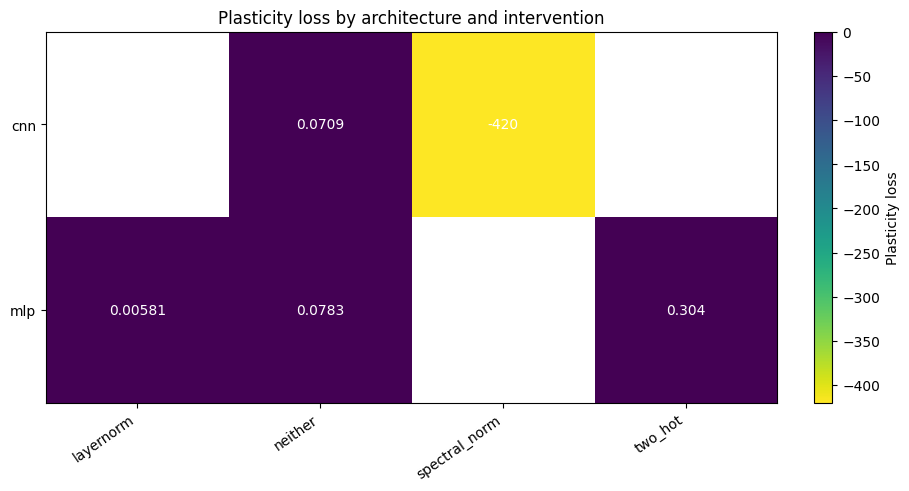

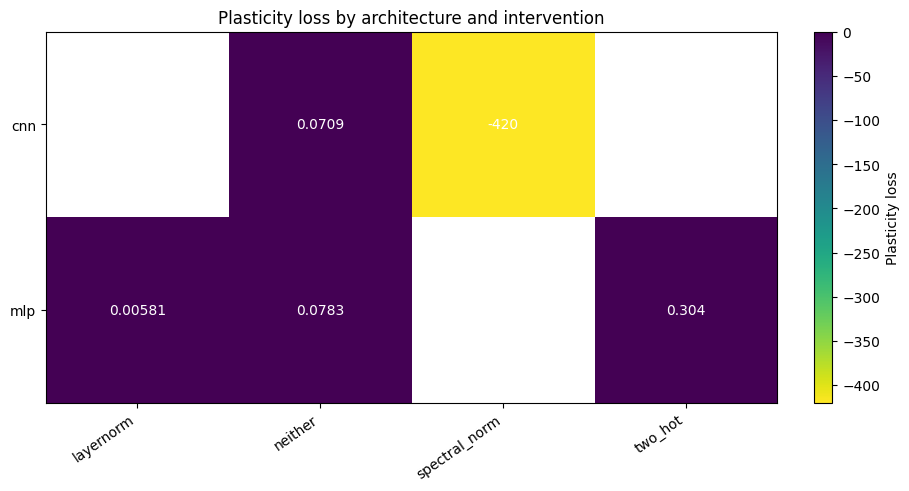

In [12]:
figure_path = FIGURES_DIR / "figure6_intervention_matrix.png"
fig = plot_intervention_matrix(intervention_df, save_path=figure_path)
fig

## Full Matrix Starting Point

Uncomment to run every architecture (MLP, CNN, ResNet18, ViT) against every intervention, across 4 seeds. Note this will raise a `ValueError` on `resnet18` configs until that architecture is implemented in `src.models` — drop it from `architectures` to run the rest of the matrix in the meantime.

In [13]:
# full_configs = make_intervention_matrix_configs(
#     data_root=str(DATA_ROOT),
#     download=False,
#     architectures=("mlp", "cnn", "resnet18", "vit"),
#     interventions=INTERVENTIONS,
#     environment="easy",
#     observation_space="mnist",
#     seeds=(0, 1, 2, 3),
# )
# len(full_configs), full_configs[0]